# #Machine Learning
# # Assignment of House Price Prediction with Multiple Linear Regression
# #MUGISHA EMMANUEL
# #26RP00370
# #ETT Y4 BTECH

# Follow Parts A-G in order.

## Part A: Data Exploration and Cleaning

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv("C:/Users/USER/Downloads/house_price_prediction_dataset .csv")
print("Shape:",df.shape)
display(df.head())
df.info()
display(df.describe(include="all"))

Shape: (125, 9)


,House_ID,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces,Neighborhood,House_Price_Million_RWF
0,1001,144.6,2.0,2.0,15.0,27.40,0.0,Kigali City,104.8
1,1002,101.9,4.0,4.0,15.5,5.97,1.0,Huye,137.0
2,1003,157.1,3.0,2.0,8.9,2.42,1.0,Nyarugenge,171.6
3,1004,254.2,3.0,2.0,15.5,6.68,1.0,Musanze,197.2
4,1005,96.7,3.0,2.0,9.5,12.34,2.0,Gasabo,121.8


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   House_ID                 125 non-null    int64  
 1   Area_m2                  123 non-null    float64
 2   Bedrooms                 124 non-null    float64
 3   Bathrooms                124 non-null    float64
 4   House_Age_Years          124 non-null    float64
 5   Distance_to_City_km      124 non-null    float64
 6   Parking_Spaces           124 non-null    float64
 7   Neighborhood             124 non-null    object 
 8   House_Price_Million_RWF  124 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 8.9+ KB


,House_ID,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces,Neighborhood,House_Price_Million_RWF
count,125.000000,123.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124,124.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Huye,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25,NaN
mean,1059.000000,134.808943,3.298387,3.016129,9.773387,5.652419,1.185484,NaN,173.254032
std,34.938887,133.300251,1.216284,1.202868,10.435564,8.701097,0.849361,NaN,127.372543
min,1001.000000,26.000000,1.000000,1.000000,0.400000,0.070000,0.000000,NaN,77.700000
25%,1028.000000,82.450000,2.000000,2.000000,3.175000,1.557500,1.000000,NaN,118.525000
50%,1058.000000,107.900000,3.000000,3.000000,6.650000,3.535000,1.000000,NaN,150.650000
75%,1089.000000,141.000000,4.000000,4.000000,12.125000,7.072500,2.000000,NaN,186.675000


In [5]:
display(df.isnull().sum().to_frame("Missing Values"))

,Missing Values
House_ID,0
Area_m2,2
Bedrooms,1
Bathrooms,1
House_Age_Years,1
Distance_to_City_km,1
Parking_Spaces,1
Neighborhood,1
House_Price_Million_RWF,1


#Explain the Reason

Drop a row with missing target. Impute numeric predictors with the median and Neighborhood with the mode because only a small number of predictor values are missing.

In [7]:
print("Duplicates:",df.duplicated().sum())
df=df.drop_duplicates().copy()

Duplicates: 5


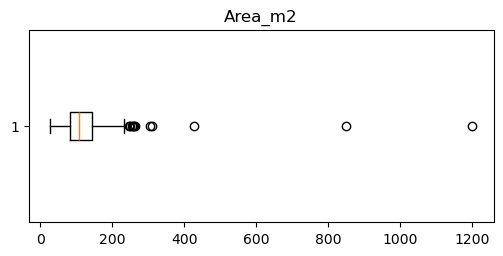

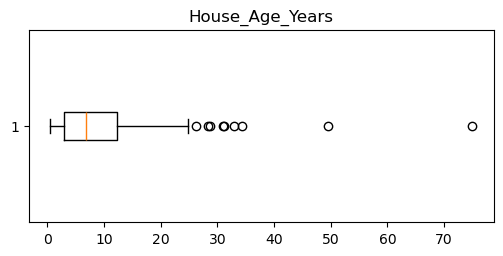

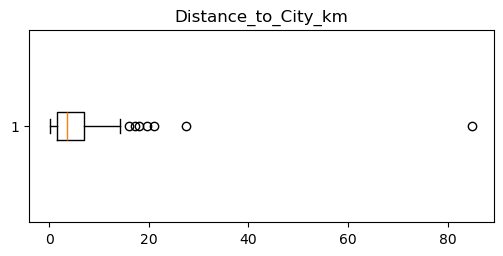

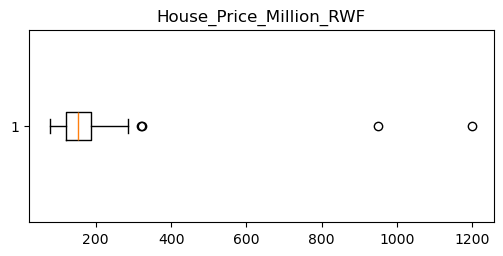

In [8]:
for col in ["Area_m2","House_Age_Years","Distance_to_City_km","House_Price_Million_RWF"]:
    plt.figure(figsize=(6,2.5)); plt.boxplot(df[col].dropna(),vert=False); plt.title(col); plt.show()

After IQR/boxplot inspection, remove House_ID 1006, 1019, 1034, 1048, 1073 and 1092 as exceptionally extreme/inconsistent records. Retain moderate but plausible outliers.

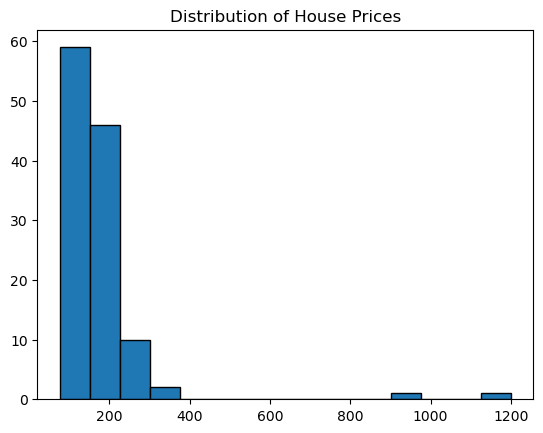

In [10]:
plt.hist(df["House_Price_Million_RWF"],bins=15,edgecolor="black");plt.title("Distribution of House Prices");plt.show()
# Interpretation: Most cleaned prices are in the lower-to-middle range, with fewer high-price houses.

In [11]:
df=df.dropna(subset=["House_Price_Million_RWF"]).copy()
df=df[~df["House_ID"].isin([1006,1019,1034,1048,1073,1092])].copy()
numeric_features=["Area_m2","Bedrooms","Bathrooms","House_Age_Years","Distance_to_City_km","Parking_Spaces"]
for c in numeric_features: df[c]=df[c].fillna(df[c].median())
df["Neighborhood"]=df["Neighborhood"].fillna(df["Neighborhood"].mode()[0])
df.to_csv("house_price_prediction_cleaned.csv",index=False)
print(df.shape); display(df.isnull().sum())

(113, 9)


House_ID                   0
Area_m2                    0
Bedrooms                   0
Bathrooms                  0
House_Age_Years            0
Distance_to_City_km        0
Parking_Spaces             0
Neighborhood               0
House_Price_Million_RWF    0
dtype: int64

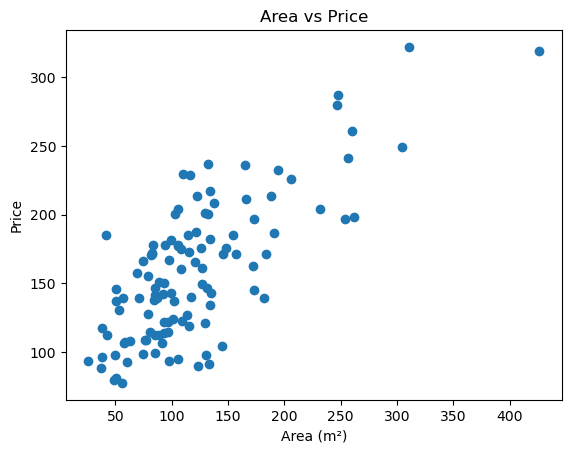

In [12]:
plt.scatter(df["Area_m2"],df["House_Price_Million_RWF"]);plt.xlabel("Area (m²)");plt.ylabel("Price");plt.title("Area vs Price");plt.show()
# Interpretation: Price generally increases as floor area increases.

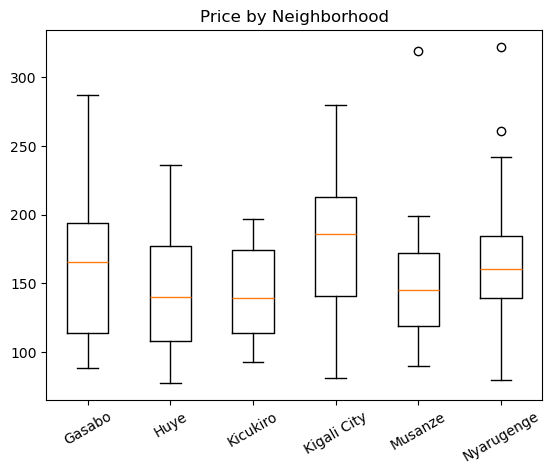

In [13]:
names=sorted(df["Neighborhood"].unique()); groups=[df.loc[df["Neighborhood"]==n,"House_Price_Million_RWF"] for n in names]
plt.boxplot(groups,tick_labels=names);plt.xticks(rotation=30);plt.title("Price by Neighborhood");plt.show()
# Interpretation: Price distributions differ across neighborhoods.

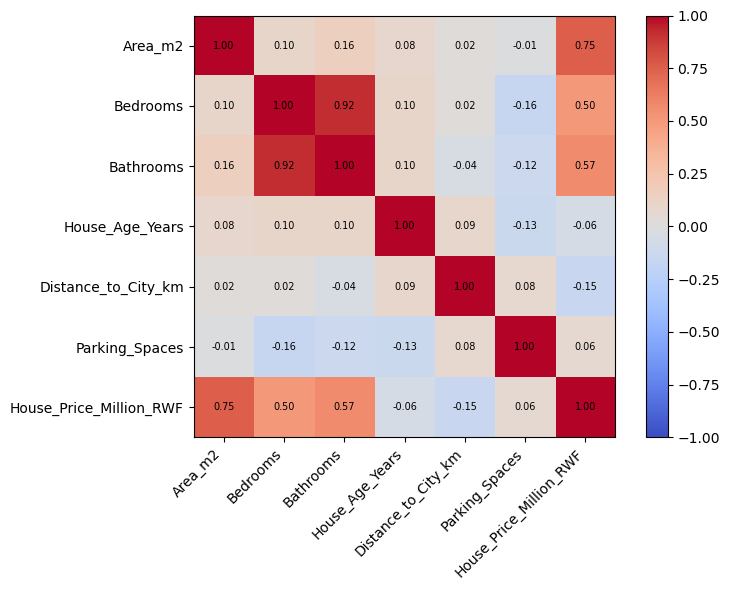

In [14]:
corr=df[numeric_features+["House_Price_Million_RWF"]].corr()
plt.figure(figsize=(8,6));im=plt.imshow(corr,vmin=-1,vmax=1,cmap="coolwarm");plt.colorbar(im);plt.xticks(range(len(corr)),corr.columns,rotation=45,ha="right");plt.yticks(range(len(corr)),corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)): plt.text(j,i,f"{corr.iloc[i,j]:.2f}",ha="center",va="center",fontsize=7)
plt.tight_layout();plt.show()
# Interpretation: Bedrooms and Bathrooms are strongly correlated.

### Cleaning decisions
| Problem | Where | Action | Reason |
|---|---|---|---|
| Missing target | Price | Drop row | Cannot train without target |
| Missing numeric | Predictors | Median impute | Robust and preserves rows |
| Missing category | Neighborhood | Mode impute | Suitable simple categorical treatment |
| Duplicates | Full rows | Remove | Avoid bias |
| Extreme anomalies | IDs 1006,1019,1034,1048,1073,1092 | Remove | Exceptionally extreme/inconsistent |
| Text category | Neighborhood | One-hot; drop first | Regression input and dummy trap |

## Part B: Building the Model

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
features=numeric_features+["Neighborhood"]; target="House_Price_Million_RWF"
X=df[features];y=df[target]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)
preprocessor=ColumnTransformer([("num",SimpleImputer(strategy="median"),numeric_features),("cat",Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("onehot",OneHotEncoder(drop="first",handle_unknown="ignore"))]),["Neighborhood"])])
model=Pipeline([("preprocessor",preprocessor),("regressor",LinearRegression())])
model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['Area_m2', 'Bedrooms',
                                                   'Bathrooms',
                                                   'House_Age_Years',
                                                   'Distance_to_City_km',
                                                   'Parking_Spaces']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Neighborhood'])])),
                ('regressor', LinearRegression())])

In [18]:
feature_names=model.named_steps["preprocessor"].get_feature_names_out()
print("Intercept:",model.named_steps["regressor"].intercept_)
display(pd.DataFrame({"Variable":feature_names,"Coefficient":model.named_steps["regressor"].coef_}))

Intercept: 29.528657513473775


,Variable,Coefficient
0,num__Area_m2,0.560317
1,num__Bedrooms,3.710935
2,num__Bathrooms,19.013659
3,num__House_Age_Years,-0.864319
4,num__Distance_to_City_km,-0.984798
5,num__Parking_Spaces,6.121449
6,cat__Neighborhood_Huye,-11.863221
7,cat__Neighborhood_Kicukiro,-11.816313
8,cat__Neighborhood_Kigali City,15.598600
9,cat__Neighborhood_Musanze,-17.231320


In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
numeric_X=df[numeric_features]
display(numeric_X.corr())
display(pd.DataFrame({"Variable":numeric_features,"VIF":[variance_inflation_factor(numeric_X.values,i) for i in range(len(numeric_features))]}))
# Bedrooms and Bathrooms show severe multicollinearity.

,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces
Area_m2,1.000000,0.100124,0.155562,0.082813,0.019543,-0.007868
Bedrooms,0.100124,1.000000,0.921282,0.096887,0.016599,-0.155084
Bathrooms,0.155562,0.921282,1.000000,0.099321,-0.043608,-0.122620
House_Age_Years,0.082813,0.096887,0.099321,1.000000,0.093212,-0.128925
Distance_to_City_km,0.019543,0.016599,-0.043608,0.093212,1.000000,0.076993
Parking_Spaces,-0.007868,-0.155084,-0.122620,-0.128925,0.076993,1.000000


,Variable,VIF
0,Area_m2,4.023023
1,Bedrooms,56.666668
2,Bathrooms,54.644014
3,House_Age_Years,2.143758
4,Distance_to_City_km,2.052041
5,Parking_Spaces,2.514679


## Part C: Evaluation and Interpretation

In [20]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import math
def adjusted_r2(r2,n,p): return 1-(1-r2)*(n-1)/(n-p-1)
p=len(feature_names); rows=[]
for name,xx,yy in [("Training",X_train,y_train),("Testing",X_test,y_test)]:
    pr=model.predict(xx);r2=r2_score(yy,pr);rows.append([name,r2,adjusted_r2(r2,len(yy),p),mean_absolute_error(yy,pr),math.sqrt(mean_squared_error(yy,pr))])
display(pd.DataFrame(rows,columns=["Dataset","R²","Adjusted R²","MAE","RMSE"]))

,Dataset,R²,Adjusted R²,MAE,RMSE
0,Training,0.881241,0.864493,14.493915,17.716925
1,Testing,0.787919,0.575839,18.375411,22.936607


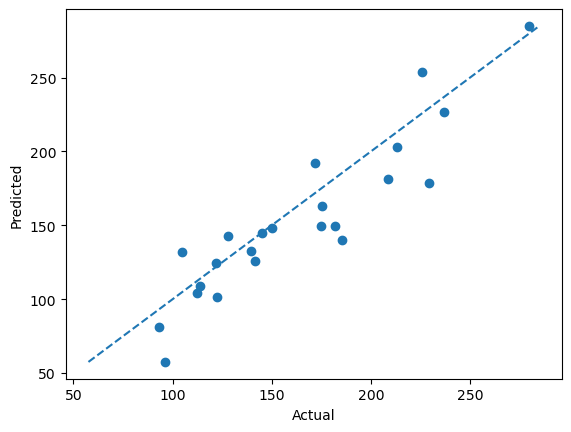

In [21]:
y_pred=model.predict(X_test);plt.scatter(y_test,y_pred);mn=min(y_test.min(),y_pred.min());mx=max(y_test.max(),y_pred.max());plt.plot([mn,mx],[mn,mx],"--");plt.xlabel("Actual");plt.ylabel("Predicted");plt.show()

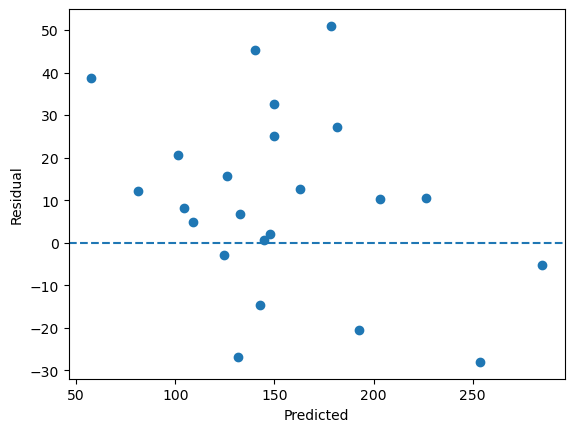

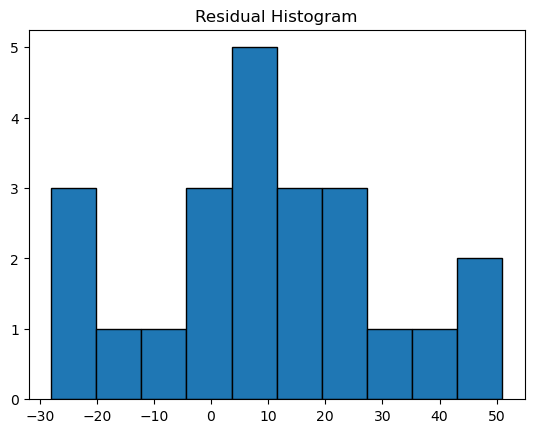

In [22]:
residuals=y_test-y_pred;plt.scatter(y_pred,residuals);plt.axhline(0,linestyle="--");plt.xlabel("Predicted");plt.ylabel("Residual");plt.show()
plt.hist(residuals,bins=10,edgecolor="black");plt.title("Residual Histogram");plt.show()

### Interpretation
- Area coefficient 0.560: one extra m² is associated with about 0.560 million RWF higher predicted price, other variables held constant.
- Bathrooms coefficient 19.014: one extra bathroom is associated with about 19.014 million RWF higher predicted price.
- House age coefficient -0.864: each extra year is associated with about 0.864 million RWF lower predicted price.

Linearity is reasonably supported; residuals are centered near zero; constant variance/normality are approximate; severe multicollinearity exists between Bedrooms and Bathrooms. Limitations: small dataset (113 cleaned observations) and omitted price drivers such as exact location, land size and construction quality.

## Part D: Saving the Model

In [23]:
import joblib
joblib.dump(model,"house_price_model.sav")
loaded_model=joblib.load("house_price_model.sav")
print("Same predictions:",np.allclose(model.predict(X_test),loaded_model.predict(X_test)))

Same predictions: True


In [24]:
new_house=pd.DataFrame([{"Area_m2":150.0,"Bedrooms":3,"Bathrooms":2,"House_Age_Years":5.0,"Distance_to_City_km":4.0,"Parking_Spaces":1,"Neighborhood":"Gasabo"}])
print(f"Predicted price: {loaded_model.predict(new_house)[0]:.2f} million RWF")

Predicted price: 160.60 million RWF


## Part E: Streamlit App
Use the supplied `app.py`. From Anaconda Prompt in the project folder run: `streamlit run app.py`.

## Part F: GitHub and Deployment
Create public `house-price-predictor`; upload all required files; make at least four meaningful commits; deploy `app.py` on Streamlit Community Cloud; test the public URL.

## Part G: Written Report
Use the supplied PDF. Add screenshots of the local and online app showing a prediction before final submission.